# Roots of Risk: Modeling Poker Strategy


## Motivation

I wanted to explore the learnability of No Limit Texas Hold Em' (NLH) poker using decision trees. NLH has become very popular over the past two decades, as visualized below by the increase in entries at the World Series of Poker Main Event. In particular, non-professional players have been entering the tournament. I wanted to learn if those players were just gambling or if they could learn to become better.

Online solvers can help players determine the best decision in any given spot, but this can be difficult to learn from, as players cannot memorize every possible decision spot. Consequently, I wanted to use decision trees to see if I could build-up accuracy for player decisions in a step-by-step, interpretable manner. I also wanted to use feature importance to see which portions of the game truly matter.

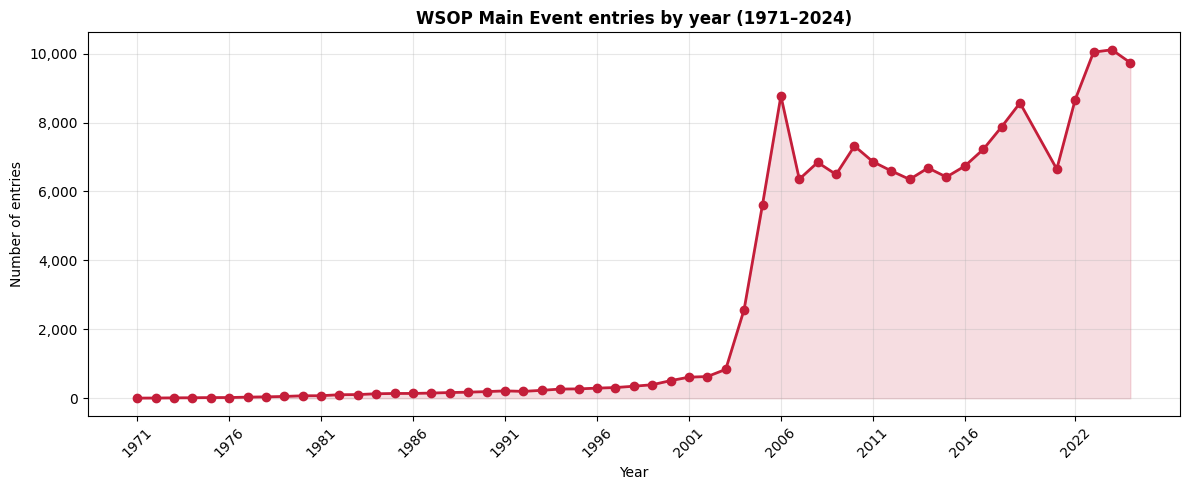

In [ ]:
import os, kagglehub
import matplotlib.pyplot as plt
import pandas as pd

wsop_path = kagglehub.dataset_download(
    'cviaxmiwnptr/wsop-main-event-results-1971-2024'
)
csv_file = [f for f in os.listdir(wsop_path) if f.endswith('.csv')][0]
wsop = pd.read_csv(os.path.join(wsop_path, csv_file))
entries_by_year = wsop.groupby('year')['entries'].first().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(entries_by_year['year'], entries_by_year['entries'],
        marker='o', linewidth=2, color='#c41e3a')
ax.fill_between(entries_by_year['year'], entries_by_year['entries'],
                alpha=0.15, color='#c41e3a')
ax.set_xlabel('Year'); ax.set_ylabel('Number of entries')
ax.set_title('WSOP Main Event entries by year (1971–2024)',
             fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(entries_by_year['year'].values[::5])
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## Setup

In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import xgboost as xgb

warnings.filterwarnings('ignore')

PROCESSED = 'data/processed'
print('Setup complete.')

Setup complete.


In [2]:
def plot_importances(clf, feature_cols, title):
    indices = np.argsort(clf.feature_importances_)[::-1]
    sorted_features = [feature_cols[i] for i in indices]
    sorted_importances = clf.feature_importances_[indices]
    plt.figure(figsize=(10, max(3, 0.4 * len(feature_cols))))
    plt.barh(sorted_features[::-1], sorted_importances[::-1],
             color='steelblue', edgecolor='black')
    plt.xlabel('Importance'); plt.ylabel('Feature')
    plt.title(title); plt.tight_layout(); plt.show()

def show_tree(clf, X):
    plt.figure(figsize=(20, 10))
    plot_tree(clf, feature_names=X.columns, class_names=clf.classes_,
              filled=True, rounded=True, fontsize=8)
    plt.show()

def fit_and_report(df_features, feature_cols, target='decision_category',
                   max_depth=5, title=''):
    """Train a depth-`max_depth` tree, print accuracies, plot importances + tree."""
    X = df_features[feature_cols]
    y = df_features[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    clf.fit(X_train, y_train)
    print(f'Train accuracy: {accuracy_score(y_train, clf.predict(X_train)):.4f}')
    print(f'Test accuracy:  {accuracy_score(y_test, clf.predict(X_test)):.4f}')
    plot_importances(clf, feature_cols, f'{title}: feature importances')
    show_tree(clf, X)
    return clf

Throughout the analysis below, I will display decision trees, the resulting accuracy, and feature importance. The above 3 functions serve as helper functions for those tasks. I have kept them in the main notebook to explore the rationale behind what results I displayed.

I chose to use accuracy as the main metric for analysis because I wanted to focus on interpretability. Accuracy provides a simple, easy to understand metric.

For most of my exploration, I kept the depth of the decision tree at 5. This limited the number of features that would be used in a single trace, which therefore granted more insight into feature importance. 

## Background

The following provides a basic explanation for Texas Hold Em' poker, played with a standard 52-card deck:
- Each player is trying to make the best 5 card hand.
- Each player is dealt two cards facedown, known as their hole cards (or sometimes holding).
- The pre-flop action occurs, which consists of betting based only on these two cards.
- The flop follows, where 3 shared cards are dealt face up.
- A round of betting occurs, starting with the player to the left of the dealer. This starts the post-flop action.
- A turn card is dealt, followed by a round of betting.
- A river card is dealt, followed by a round of betting.
- Players only use 5/7 possible cards to make their final hand.
- Highest hand wins according to the following chart: 
- ![Poker Hand Ranks](assets/poker_hand_strength.webp)
- An example board can be seen here: 
- ![Poker Board Example](assets/poker_board_example.webp)

With regards to making decisions, players are deciding when and how much to bet. The following options exist:
- When facing a bet, players must either:
    - Call the bet (pay the same amount)
    - Fold (give up their cards)
    - Raise (increase the bet)
- Otherwise, a player can:
    - Check (pass the action)
    - Bet (force others to decide)
- 2 players must always bet a fixed amount pre-flop to start the pot

Game-Theory Optimal poker was built by having AI play against itself to find a Nash Equilibrium. It uses a balanced strategy that plays a range of hands in a similar manner to avoid giving away information through its bets. It is considered unexploitable and therfore often the "correct" decision. My decision trees will be attempting to determine what decision a GTO solver suggests: Check, Call, Fold, or Bet / Raise.

## Data

I am using the PokerBench post-flop dataset, which consists of 500k rows with a GTO-labeled correct decision. Each row is one decision point that shows:
- Hole cards
- Board so far 
- Preflop + postflop action
- Available moves
- GTO-correct decision

Cleaning and preprocessing are done in `scripts/build_features.py`. During preprocessing, I simplified the correct_decision column. Rather than show a specific amount to bet or raise, all bets / raises were condensed into a single "Bet/Raise" label.

I implemented additional preprocessing and feature engineering for each player profile built. The exact preprocessing per profile is described below. 

Exploratory Data Analysis shows a balanced distribution of decision categories, with a distribution of hands that reflects pre-flop GTO play. It is more heavily weighted toward decisions on the River, followed by the Turn, and finally on the Flop.

The dataset is limited in being able to prove the learnability of all of poker since it just analyzes post-flop decisions. It also assumes that GTO play is inherently correct, which makes it less able to model low stakes poker that sees a different distribution of hole cards played post-flop.

Additionally, due to my pre-processing, the dataset has limits on predicting the correct bet sizing. Instead, it is only labeled into the overarching action categories.

In [4]:
df_simplified = pd.read_parquet(f'{PROCESSED}/df_simplified.parquet')
print(f'{len(df_simplified):,} rows')
df_simplified.head()

500,000 rows


,preflop_action,board_flop,board_turn,board_river,aggressor_position,postflop_action,evaluation_at,pot_size,hero_position,holding,available_moves_simplified,decision_category
0,HJ/2.0bb/BB/call,JcJh4s,4d,As,OOP,OOP_CHECK/IP_BET_1/OOP_CALL/dealcards/4d/OOP_C...,River,21,IP,AhKd,"Bet/Raise,Check",Check
1,SB/3.0bb/BB/call,6s8d7c,9s,3c,OOP,OOP_CHECK/IP_CHECK/dealcards/9s/OOP_BET_5/IP_R...,Turn,27,OOP,Tc9c,"Bet/Raise,Call,Fold",Call
2,UTG/2.0bb/CO/6.5bb/UTG/call,JcJh4s,4d,As,IP,OOP_CHECK/IP_BET_7/OOP_RAISE_16/IP_CALL/dealca...,Turn,151,IP,QsQh,"Call,Fold",Call
3,UTG/2.0bb/BTN/call,Th3s2d,5d,3c,OOP,OOP_CHECK/IP_CHECK/dealcards/5d/OOP_BET_6/IP_C...,River,17,IP,JcTc,"Bet/Raise,Check",Check
4,CO/2.3bb/BB/call,Ks7h2d,Jc,Qc,OOP,OOP_CHECK/IP_CHECK/dealcards/Jc/OOP_CHECK/IP_B...,River,39,IP,Ac5c,"Bet/Raise,Check",Bet/Raise


## Research Questions

Overall, I wanted to learn if poker was learnable, and if so, how could players learn poker? I was specifically interested in the step-by-step nature of decision trees. This led me to the following research questions:

1. Does incorporating more data improve a decision tree’s accuracy in predicting the GTO-approved decision (check, call, bet, raise, fold)? I broke "more data" into the following subquestions:
    - The number of available features / context (player profiles)
    - The depth of the tree in combining features / nuancing decisions
    - The type of decision tree model
2. Which game-state variables most effectively predict the GTO-approved decision? 

I explore these questions by building up player profiles. Each profile gains more features available to its decision tree, set at a depth of 5. I then see how accuracy improved and which features were most important. After adding in all the features, I explored increasing depth to see how accuracy and feature importance would change. Finally, I explored more a more advanced model of decision tree (XGBoost) to see how performance compared against the more visualizable models.

The following categories of player profiles exist:
- Basic players only focus on information related to their own hand, not their opponents
- Intermediate players incorporate information related to actions and possible strength of their opponents
- Advanced players incorporate more raw data and advanced models of thinking

## Baseline

To establish a baseline to compare my models against, I calculated what accuracy randomly selecting from the available moves would achieve. I computed both the analytical expectation and simulated the average, which both produced just under 41% accuracy.

In [5]:
moves = df_simplified['available_moves_simplified'].str.split(',')
expected_accuracy = (1 / moves.apply(len)).mean()
print(f'Expected random-baseline accuracy: {expected_accuracy:.4f} '
      f'({expected_accuracy*100:.2f}%)')

print('\nAvailable-move counts:')
print(moves.apply(len).value_counts().sort_index())

Expected random-baseline accuracy: 0.4097 (40.97%)

Available-move counts:
available_moves_simplified
2    229006
3    270994
Name: count, dtype: int64


In [6]:
rng = np.random.default_rng(42)
n_runs = 10
accuracies = []
for _ in range(n_runs):
    guesses = moves.apply(lambda m: rng.choice(m))
    accuracies.append((guesses == df_simplified['decision_category']).mean())
print(f'Simulated random accuracy ({n_runs} runs): '
      f'{np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}')

Simulated random accuracy (10 runs): 0.4094 ± 0.0004


Additionally, from the research paper “PokerBench: Training Large Language Models to Become Professional Poker Players," I learned that a pre-trained ChatGPT-4 model achieved an action accuracy of 62.69%. The fine-tuned LLAMA-3 model achieved action accuracy of 79.07%. Action accuracy directly maps into the decision categories I established for my decision tree models.

## Level 1 — Basic Player (Hole Only)

Level 1 players only incorporated aggregations of own two hole cards and the available moves. The preprocessing and resulting data is explained and displayed below.

They have the following features related to their hole cards: rank_sum, rank_max, is_pair
- is_pair means their two hole cards are the same, which offers immediate strength.
- Rank is a numerical representation of: Ace, King, Queen, Jack, 10, 9, ..., 2.
- For example, in row 2 below, the player has a pair of Queens for their hold cards, which is why the rank_sum is 24, rank_max is 12, and they have the is_pair flag set to true.

They have the following features related to their move availability: facing_bet, can_bet_raise
- facing_bet means a player can call / fold. They can raise unless the bet they're facing already puts them all in.
- Otherwise, the player can check / bet.

In [7]:
df_own_hand = pd.read_parquet(f'{PROCESSED}/df_own_hand.parquet')
df_own_hand.head()

,decision_category,is_pair,rank_sum,rank_max,facing_bet,can_bet_raise
0,Check,0,27,14,0,1
1,Call,0,19,10,1,1
2,Call,1,24,12,1,0
3,Check,0,21,11,0,1
4,Bet/Raise,0,19,14,0,1


Train accuracy: 0.5469
Test accuracy:  0.5463


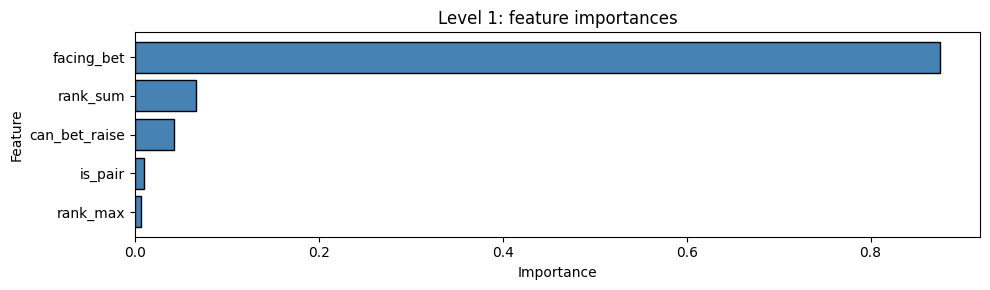

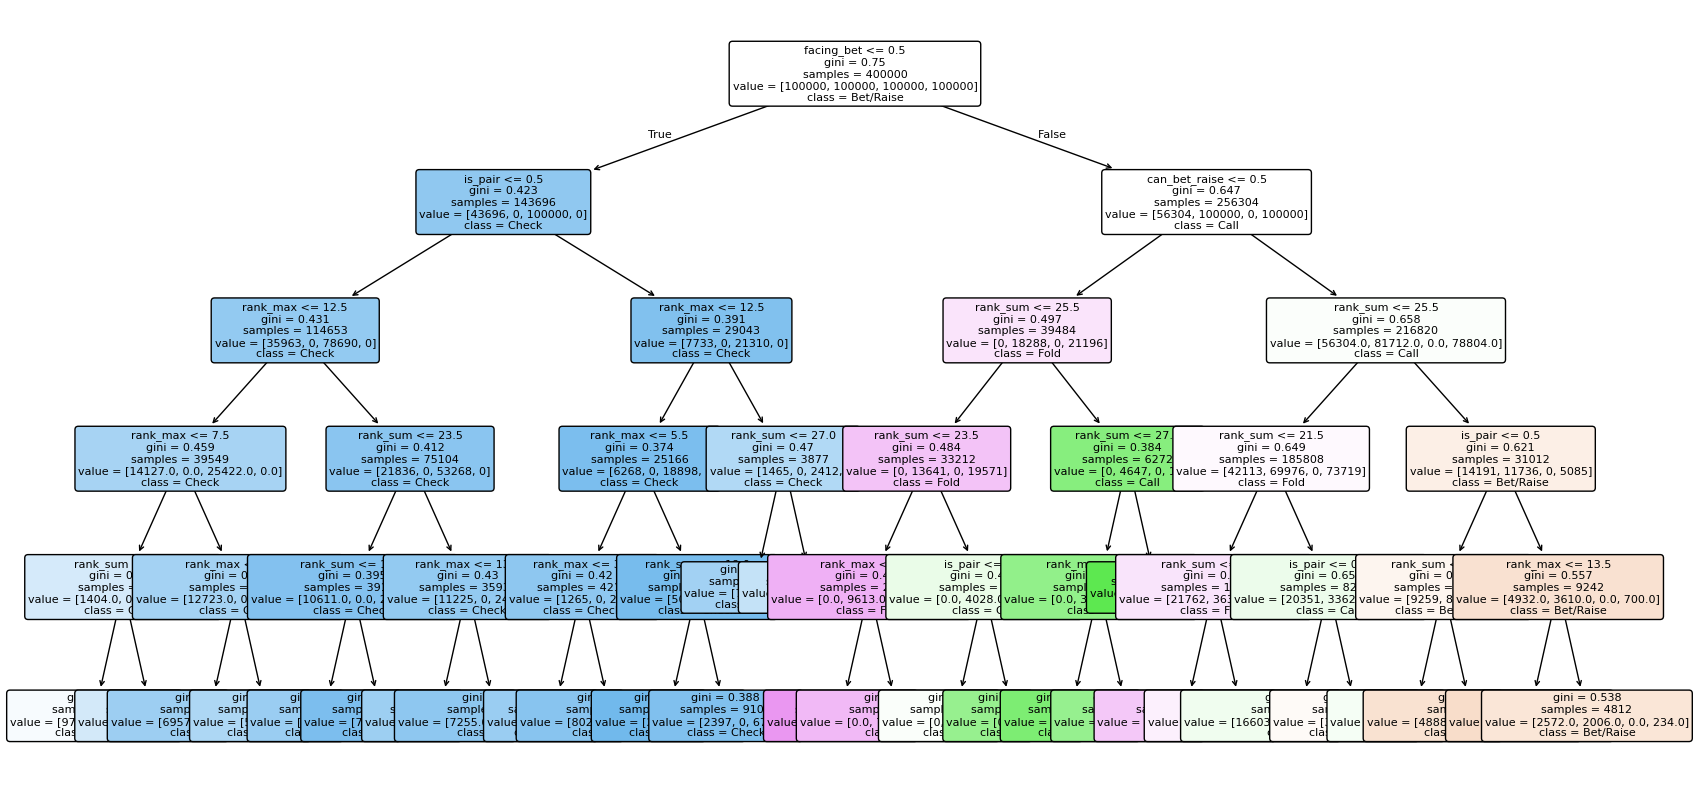

DecisionTreeClassifier(max_depth=5, random_state=42)

In [8]:
feature_cols = ['is_pair', 'rank_sum', 'rank_max', 'can_bet_raise', 'facing_bet']
fit_and_report(df_own_hand, feature_cols, title='Level 1')

With the limited information, the accuracy beats the random baseline but falls short of the LLMs. We can see that whether or not a player is facing a bet is by far the most important feature. This makes sense, since the feature is directly tied to which actions a player can take. In this case, if a player is not facing a bet, the model always prefers to check, which showcases a good beginner strategy.

## Level 2 — Basic Player (Hand Strength)

Level 2 players add a 5-card hand evaluation to their list of features. Based on all the known cards (hole cards, flop cards, and possibly turn/river cards), the best possible hand for the player is determined.

There are 7,462 possible ranks in the game when considering tiebreakers. For example, although all 3-of-a-kind hands beat any two-pair hands, a 3-of-a-kind of Aces would beat a 3-of-a-kind of Kings, making it a higher rank. For demonstration below, I have included a "hand_category" column that is more readable than the rank, but this is removed in the actual decision tree.

Since this calculation requires knowing how many cards have been revealed, a feature that represents the round of betting called "street" has been encoded as a number (3 for river, 2 for turn, 1 for flop).

In [9]:
df_hand_strength_final = pd.read_parquet(
    f'{PROCESSED}/df_hand_strength_final.parquet'
)
df_hand_strength_final.head()

,decision_category,is_pair,rank_sum,rank_max,can_bet_raise,facing_bet,hand_category,hand_rank,street
0,Check,0,27,14,1,0,two_pair,2523,3
1,Call,0,19,10,1,1,straight,2829,2
2,Call,1,24,12,0,1,two_pair,2388,2
3,Check,0,21,11,1,0,two_pair,2245,3
4,Bet/Raise,0,19,14,1,0,high_card,711,3


Train accuracy: 0.6363
Test accuracy:  0.6368


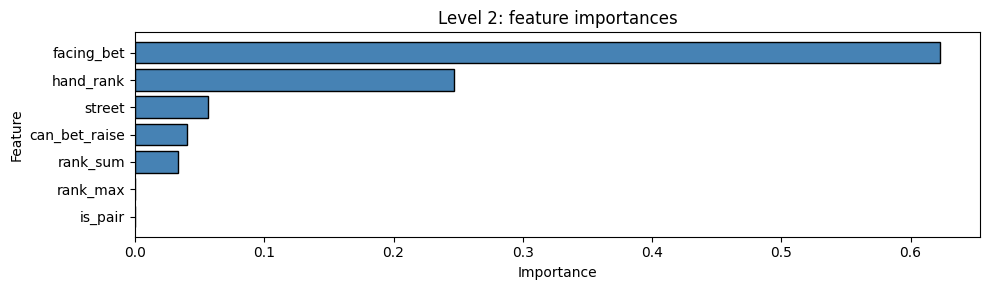

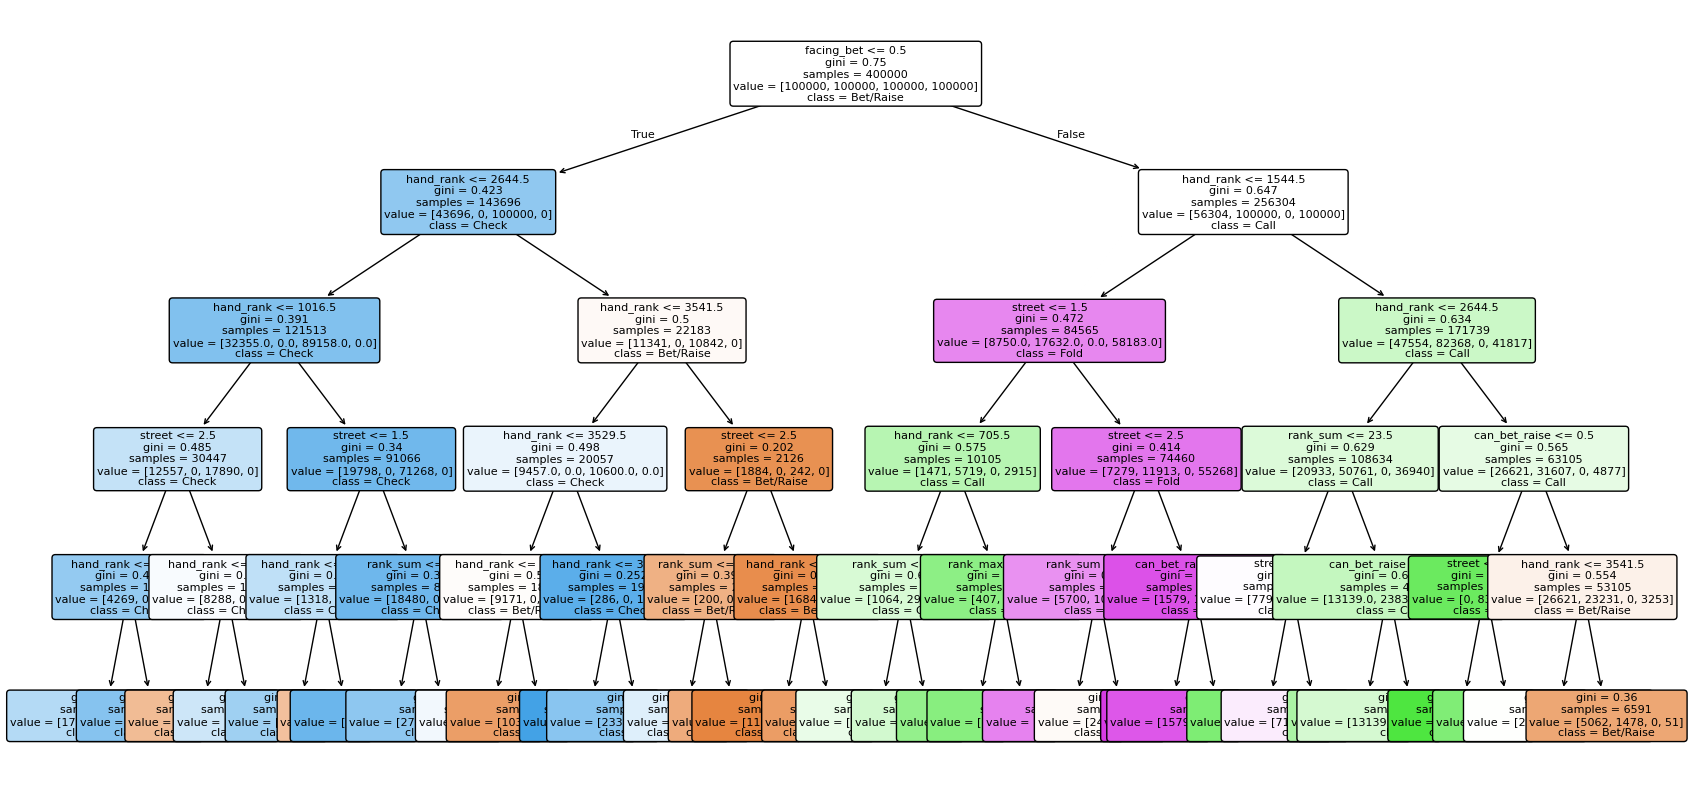

DecisionTreeClassifier(max_depth=5, random_state=42)

In [10]:
# Drop the human-readable category before training (we use the ordinal rank)
df_l2 = df_hand_strength_final.drop(columns=['hand_category'])
feature_cols = ['is_pair', 'rank_sum', 'rank_max', 'can_bet_raise',
                'facing_bet', 'hand_rank', 'street']
fit_and_report(df_l2, feature_cols, title='Level 2')

Adding those two features creates a large jump in accuracy to 63%, which is sufficient to beat unspecialized LLMs. This is reflected in the more nuanced decision tree, with bets / raises getting mixed into decision spots that were previously checks.

A hand's strength becomes the second most important feature, with street becoming the third most important feature. This importance explains the large gains in accuracy. Early features such as rank_max, and is_pair already become completely irrelevant.

## Level 3 — Basic Player (Max Future Strength)

Level 3 players add a feature that calculates the maximum rank their hand could achieve on future streets. On river decisions, such as in row 0, this is the same as their current hand rank, since no more cards will be dealt.

This preprocessing is achieved by walking down the hand-rank ladder from a top-down approach and stopping at the first reachable category, which saves time compared to calculating every possible game state and then computing the highest strength.

In [11]:
df_max_strength_final = pd.read_parquet(
    f'{PROCESSED}/df_max_strength_final.parquet'
)
df_max_strength_final.head()

,decision_category,is_pair,rank_sum,rank_max,can_bet_raise,facing_bet,hand_category,hand_rank,street,max_future_rank
0,Check,0,27,14,1,0,two_pair,2526,3,2526
1,Call,0,19,10,1,1,straight,2905,2,2906
2,Call,1,24,12,0,1,two_pair,2391,2,3836
3,Check,0,21,11,1,0,two_pair,2248,3,2248
4,Bet/Raise,0,19,14,1,0,high_card,711,3,711


Train accuracy: 0.6491
Test accuracy:  0.6486


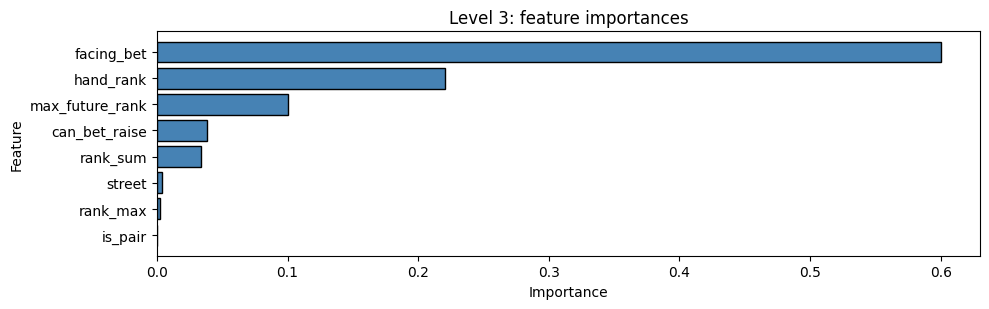

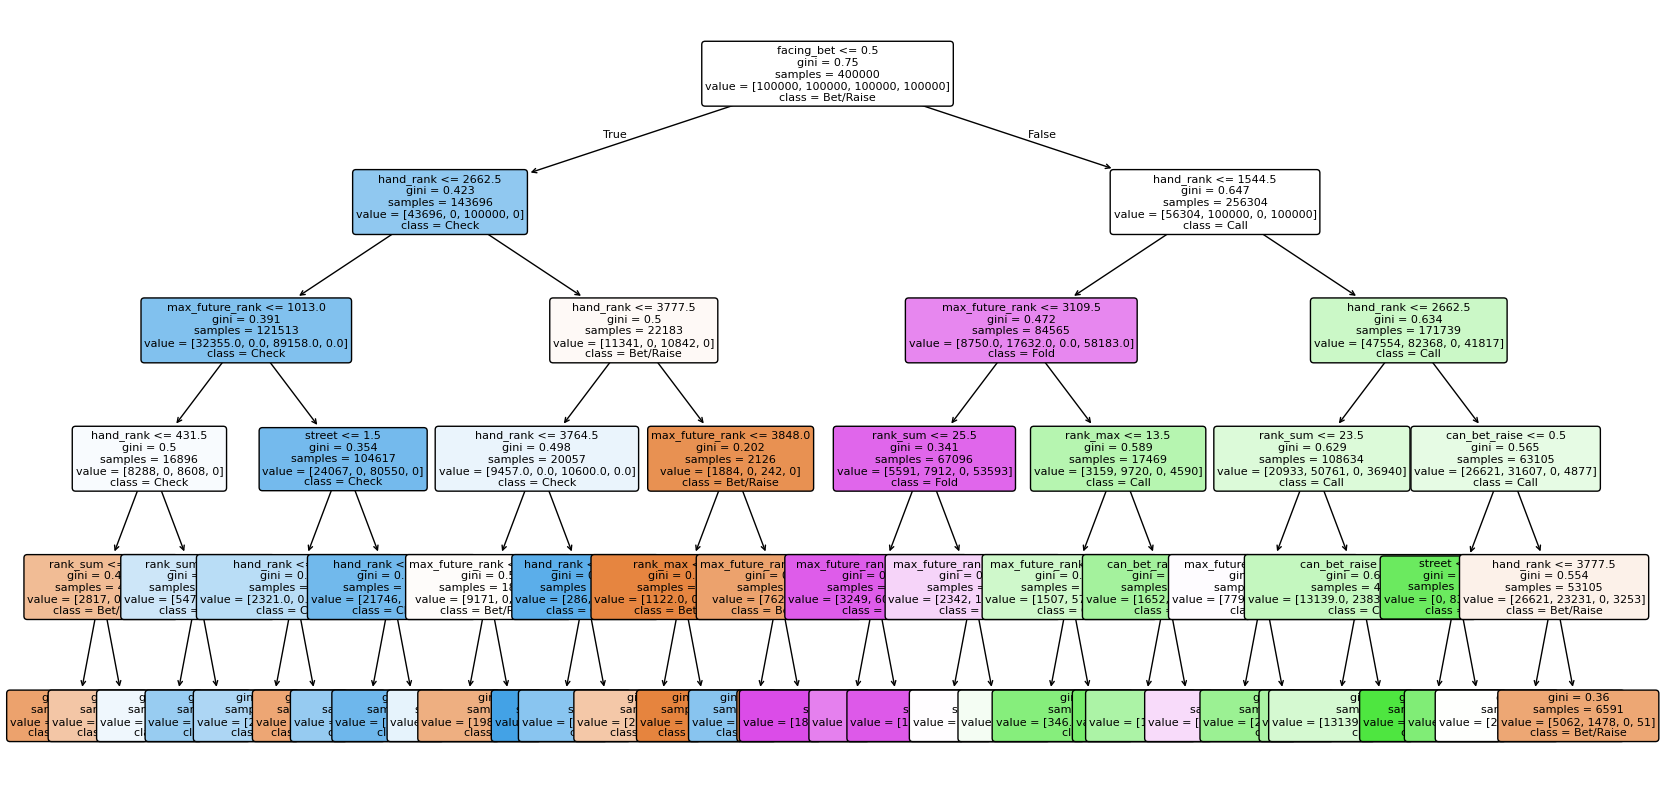

DecisionTreeClassifier(max_depth=5, random_state=42)

In [12]:
df_l3 = df_max_strength_final.drop(columns=['hand_category'])
feature_cols = ['is_pair', 'rank_sum', 'rank_max', 'can_bet_raise',
                'facing_bet', 'hand_rank', 'max_future_rank', 'street']
fit_and_report(df_l3, feature_cols, title='Level 3')

The accuracy only slightly improves to 64%, which is reflected in the decision tree barely changing. However, the max_future_rank feature is the third most important feature.

By adding in the max_future_rank feature, the street feature became significantly less relevant, which explains the smaller jump in accuracy. This makes sense, since the combination of hand_rank and max_future_rank can encode information related to the street. If the two are equal, the street must be the river. As a general rule, the closer they are, the later the street should be, since less cards will be dealt to improve hand_rank. In general, max_future_rank should be higher on earlier streets, since more cards will be dealt that can improve a hand_rank. 

This is a good example of why building up through player profiles matter. I know that street is a relevant feature from earlier models, but its effect is hidden in later models. Based on these results, players can learn to consider street in the context of how their hand can improve.

## Level 4 — Intermediate Player (Opponent's Nut)

Level 4 players calculate the best possible hand their opponents can plausibly achieve in future streets. This is preprocessed in a similar manner to the player's own max_future_rank. 

The player's own hole cards can serve as "blockers"; we know those cards will not appear in the opponent's hole or on later streets, since we already have them. The preprocessing also accounts for this.

Since the opponents could have any 2 cards, their maximum possible strength is often larger than the player's. However, if the player has the best possible hand or access to it, that can be a very telling signal.

In [13]:
df_nut_strength_final = pd.read_parquet(
    f'{PROCESSED}/df_nut_strength_final.parquet'
)
df_nut_strength_final.head()

,decision_category,is_pair,rank_sum,rank_max,can_bet_raise,facing_bet,hand_category,hand_rank,street,max_future_rank,opponent_nut_rank
0,Check,0,27,14,1,0,two_pair,2526,3,2526,3958
1,Call,0,19,10,1,1,straight,2906,2,2907,3993
2,Call,1,24,12,0,1,two_pair,2391,2,3837,3958
3,Check,0,21,11,1,0,two_pair,2248,3,2248,3879
4,Bet/Raise,0,19,14,1,0,high_card,711,3,711,2910


Train accuracy: 0.6491
Test accuracy:  0.6485


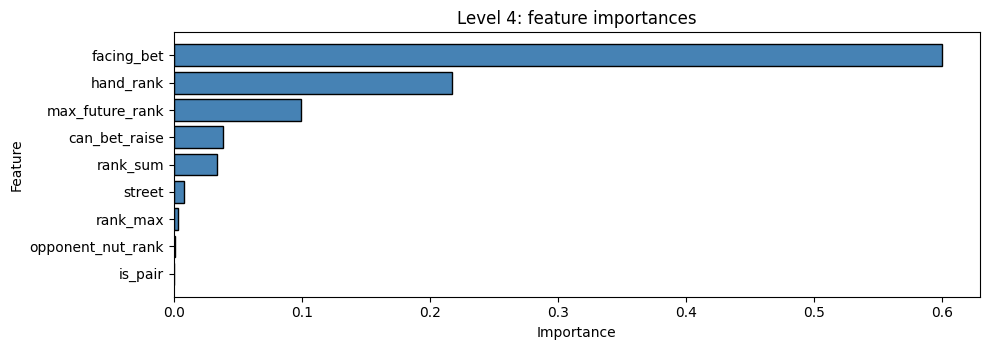

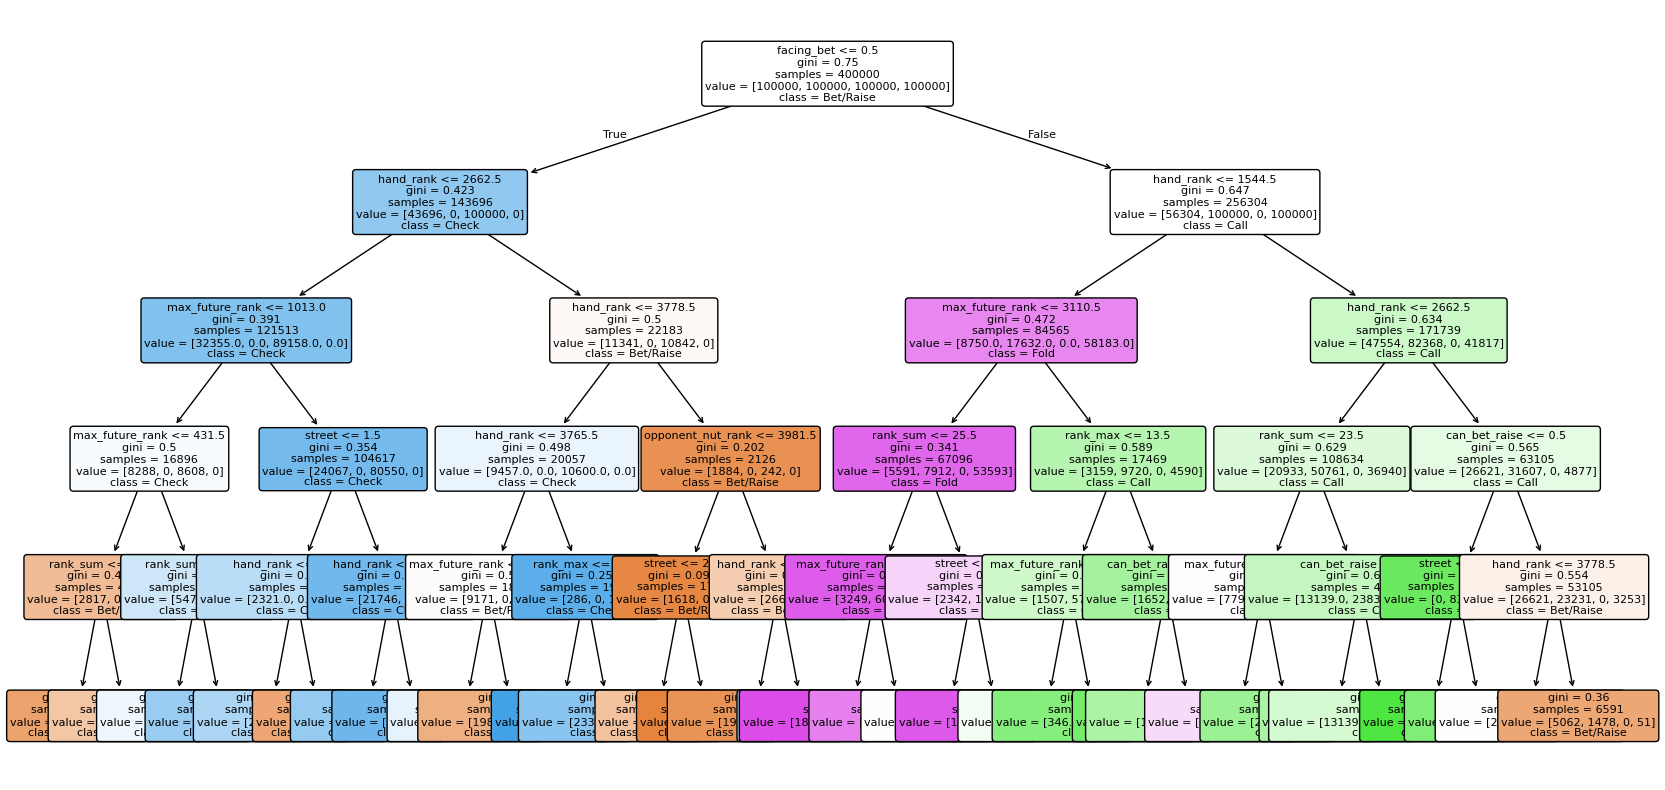

DecisionTreeClassifier(max_depth=5, random_state=42)

In [14]:
df_l4 = df_nut_strength_final.drop(columns=['hand_category'])
feature_cols = ['is_pair', 'rank_sum', 'rank_max', 'can_bet_raise',
                'facing_bet', 'hand_rank', 'max_future_rank', 'street',
                'opponent_nut_rank']
fit_and_report(df_l4, feature_cols, title='Level 4')

The accuracy barely improves, as the feature is barely utilized. This could be caused by a lack of depth in the tree, which is explored later in the project.

## Level 5 — Intermediate Players (Board Context)

Level 5 players gain access to a variety of features. Firstly, they get to know if they're in position or out of position, which indicates if they have to make their initial decisions before or after their opponents. 

Secondly, they learn the pot size, which is the total amount of money bet by all players so far. This is represented as a multiplier of the mandatory initial bets placed in the pre-flop action. 

Finally, they learn if the aggressor (first person to bet in a round) was in position or out of position. A good example is row 2. The player was the in position aggressor, so both flags are set to true. The player then got raised all in, so they are now facing a bet and cannot raise. As a result, the pot size is quite large, at 151.

In [15]:
df_context = pd.read_parquet(f'{PROCESSED}/df_context.parquet')
df_context.head()

,decision_category,is_pair,rank_sum,rank_max,can_bet_raise,facing_bet,hand_category,hand_rank,street,max_future_rank,opponent_nut_rank,pot_size,hero_position,aggressor_position
0,Check,0,27,14,1,0,two_pair,2526,3,2526,3958,21,1,0
1,Call,0,19,10,1,1,straight,2906,2,2907,3993,27,0,0
2,Call,1,24,12,0,1,two_pair,2391,2,3837,3958,151,1,1
3,Check,0,21,11,1,0,two_pair,2248,3,2248,3879,17,1,0
4,Bet/Raise,0,19,14,1,0,high_card,711,3,711,2910,39,1,0


Train accuracy: 0.6766
Test accuracy:  0.6772


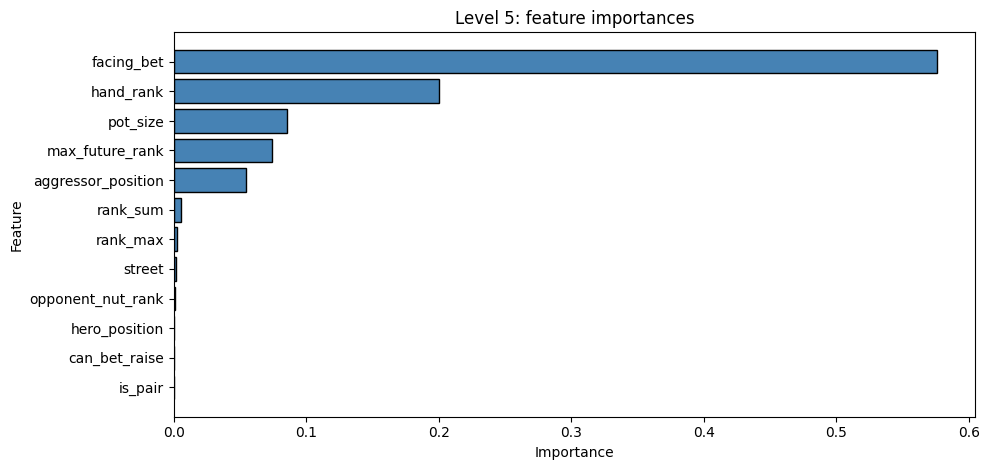

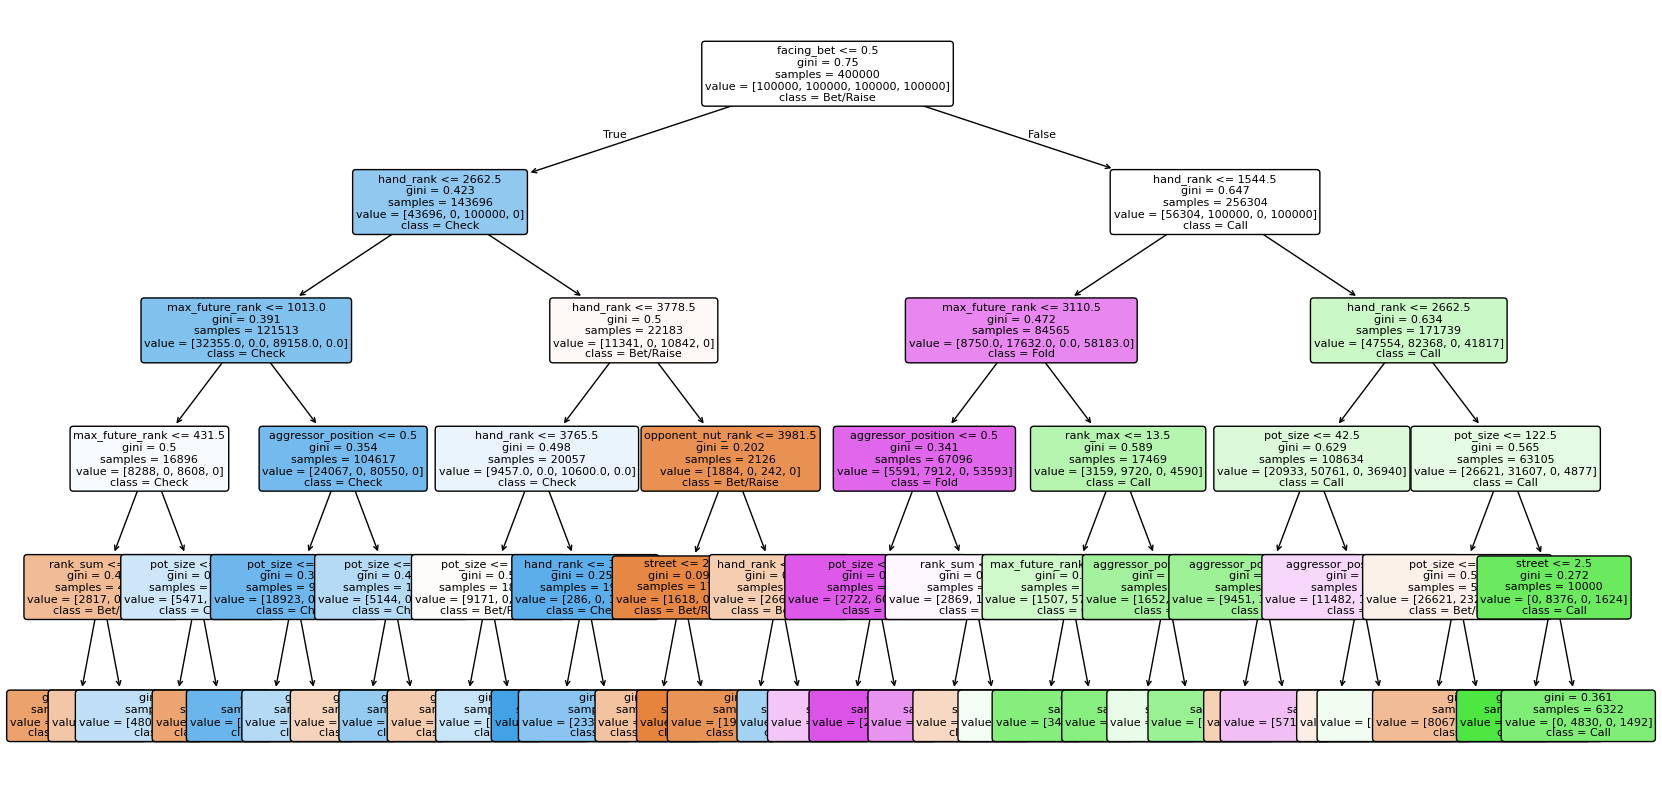

DecisionTreeClassifier(max_depth=5, random_state=42)

In [16]:
df_l5 = df_context.drop(columns=['hand_category'])
feature_cols = ['is_pair', 'rank_sum', 'rank_max', 'can_bet_raise',
                'facing_bet', 'hand_rank', 'max_future_rank', 'street',
                'opponent_nut_rank', 'pot_size', 'hero_position',
                'aggressor_position']
fit_and_report(df_l5, feature_cols, title='Level 5')

Adding in these features results in a small boost in accuracy to 67%. Both pot_size and aggressor_position are relevant features.

The decision tree observes some nuances regarding fold versus call decisions. This makes sense in the context of pot_size, since it represents an expected value calculation. If the odds of a player improving their hands are low, but the potential reward is high, the player would be incentivized to call.

## Level 6 — Intermediate Player (Action Sequences)

Level 6 players consider information contained in the betting sequences. Aggregate data is engineered by parsing the text strings. These include preflop and postflop aggregations, as summarized below:

- Preflop:
    - Number of raises
    - Number of players remaining
    - Last raise size
- Postflop:
    - Number of bets / raises on the current street
    - Last bet size relative to the pot size

In [17]:
df_action = pd.read_parquet(f'{PROCESSED}/df_action.parquet')
df_action.head()

,decision_category,is_pair,rank_sum,rank_max,can_bet_raise,facing_bet,hand_category,hand_rank,street,max_future_rank,opponent_nut_rank,pot_size,hero_position,aggressor_position,pre_num_raises,pre_num_players,pre_last_raise_bb,post_bets_raises,post_last_bet_pct_pot
0,Check,0,27,14,1,0,two_pair,2526,3,2526,3958,21,1,0,1,2,2.0,0,0.000000
1,Call,0,19,10,1,1,straight,2906,2,2907,3993,27,0,0,1,2,3.0,2,0.592593
2,Call,1,24,12,0,1,two_pair,2391,2,3837,3958,151,1,1,2,2,6.5,2,0.509934
3,Check,0,21,11,1,0,two_pair,2248,3,2248,3879,17,1,0,1,2,2.0,0,0.000000
4,Bet/Raise,0,19,14,1,0,high_card,711,3,711,2910,39,1,0,1,2,2.3,0,0.000000


Train accuracy: 0.6805
Test accuracy:  0.6813


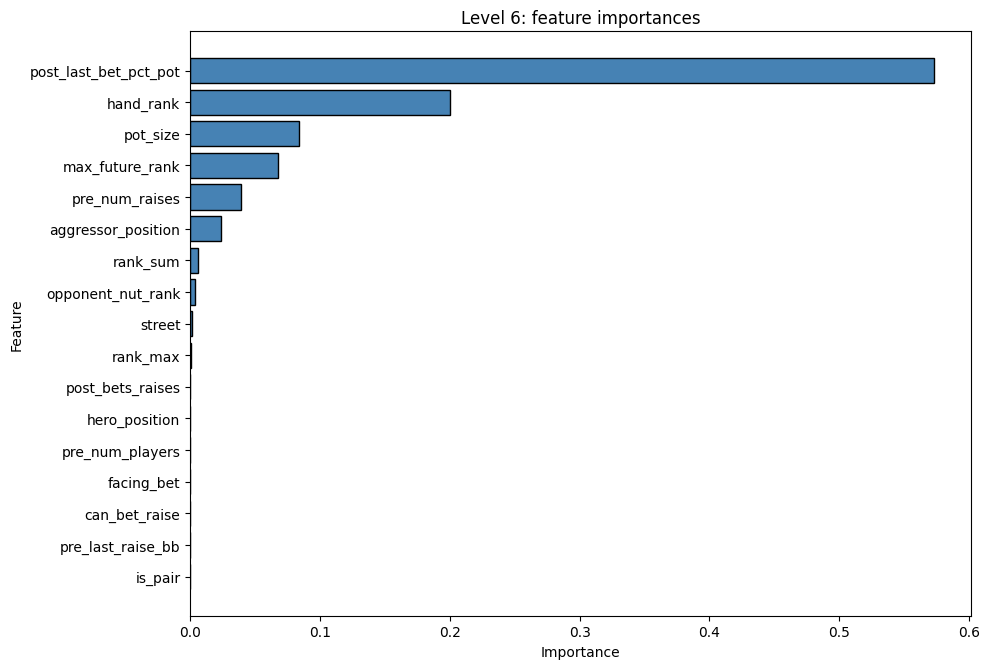

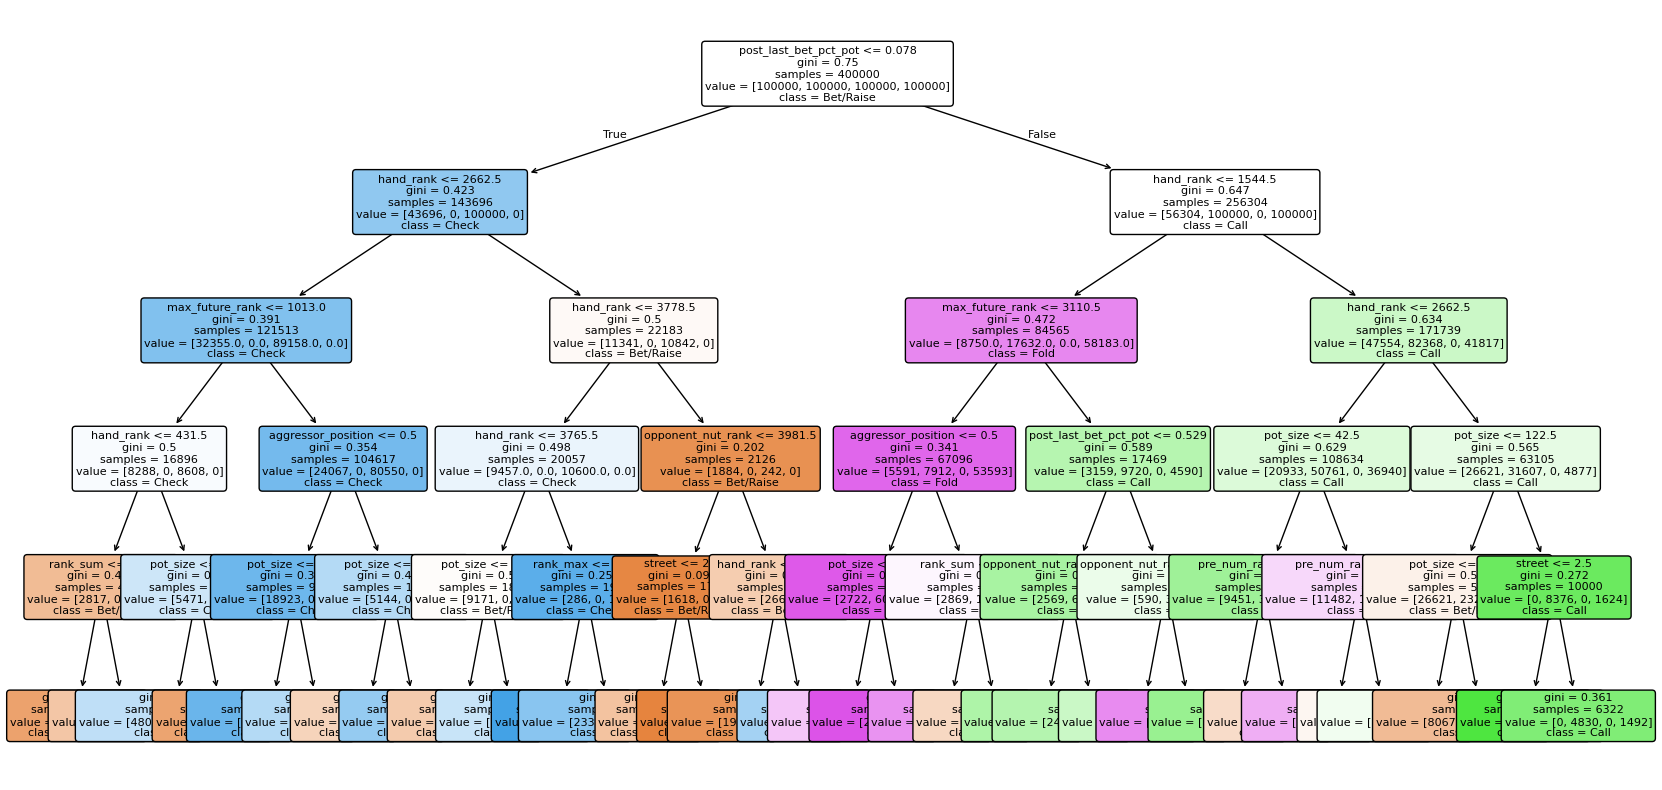

DecisionTreeClassifier(max_depth=5, random_state=42)

In [18]:
df_l6 = df_action.drop(columns=['hand_category'])
feature_cols = ['is_pair', 'rank_sum', 'rank_max', 'can_bet_raise',
                'facing_bet', 'hand_rank', 'max_future_rank', 'street',
                'opponent_nut_rank', 'pot_size', 'hero_position',
                'aggressor_position', 'pre_num_raises', 'pre_num_players',
                'pre_last_raise_bb', 'post_bets_raises',
                'post_last_bet_pct_pot']
fit_and_report(df_l6, feature_cols, title='Level 6')

This results in another small increase in accuracy to 68%. 

The last bet size relative to the pot size becomes the most relevant feature. This makes sense, since if it is non-zero, it indicates that the player is facing a bet, while also offering additional information. It effectively replaces the facing bet feature previously observed, which can be seen by it taking the first node in the decision tree.

The only other largely relevant feature at this depth was the number of raises preflop. This information is good for putting an opponent on a range of possible hands; if they're willing to raise other players without seeing any additional cards, their hole cards are likely strong.



## Exploring Tree Depth

After incorporating all the features from the original dataset, I explored how increasing the depth of the decision tree would affect accuracy and feature importance. I swept from a depth of 1 to 20 and plotted the train vs. test accuracy to avoid overfitting. I examined the depth with the best test accuracy for feature importance, which occurred at a depth of 20.

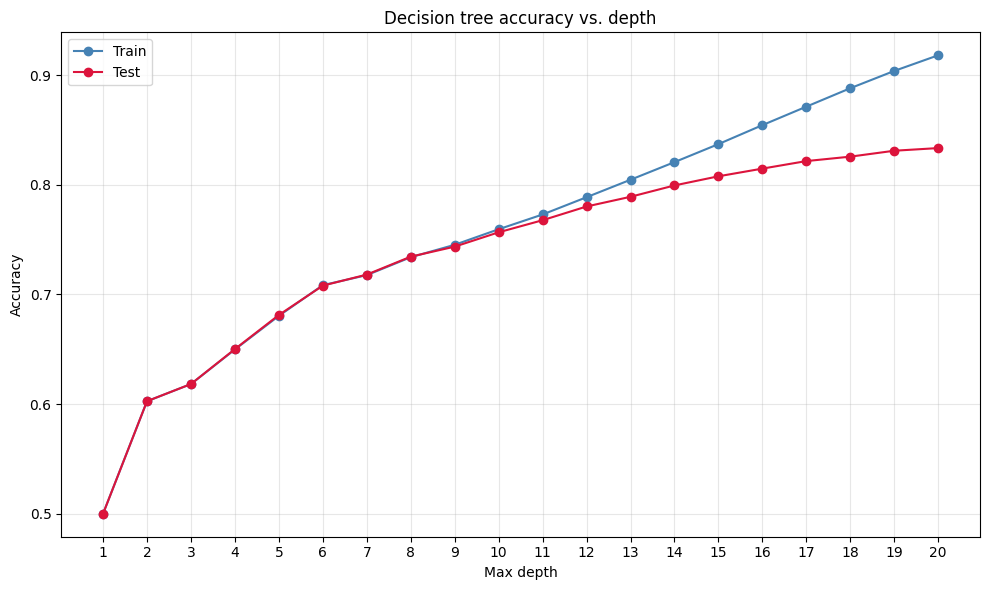

Best test accuracy: 0.8335 at depth 20


In [19]:
df_full = df_action.drop(columns=['hand_category'])
feature_cols = [c for c in df_full.columns if c != 'decision_category']
X = df_full[feature_cols]
y = df_full['decision_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

depths = list(range(1, 21))
train_accs, test_accs = [], []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_accs, marker='o', label='Train', color='steelblue')
plt.plot(depths, test_accs, marker='o', label='Test', color='crimson')
plt.xlabel('Max depth'); plt.ylabel('Accuracy')
plt.title('Decision tree accuracy vs. depth')
plt.xticks(depths); plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

best_idx = int(np.argmax(test_accs))
best_depth = depths[best_idx]
print(f'Best test accuracy: {test_accs[best_idx]:.4f} at depth {best_depth}')

I observed that accuracy went up with depth. Compared to the 68% accuracy achieved at depth 5, a large 15% improvement to 83% came simply by increasing depth to 20. This is enough to beat LLMs trained on poker data.

The test accuracy does start to plateau, suggesting an eventual limit to improvement provided by the features available. Furthermore it diverges from the training accuracy at a depth of 10, showing that the generalization starts to become more poor.

From this, I observed that poker is fairly nuanced. Decision trees need high depth to make more accurate predictions. Although a depth 20 tree isn't easily visualizable or learnable, it is worth studying an increased number of decision spots as a player, since a few simple rules will not suffice. This lends itself to the best poker players intentionally studying the online solvers to understand the nuance.

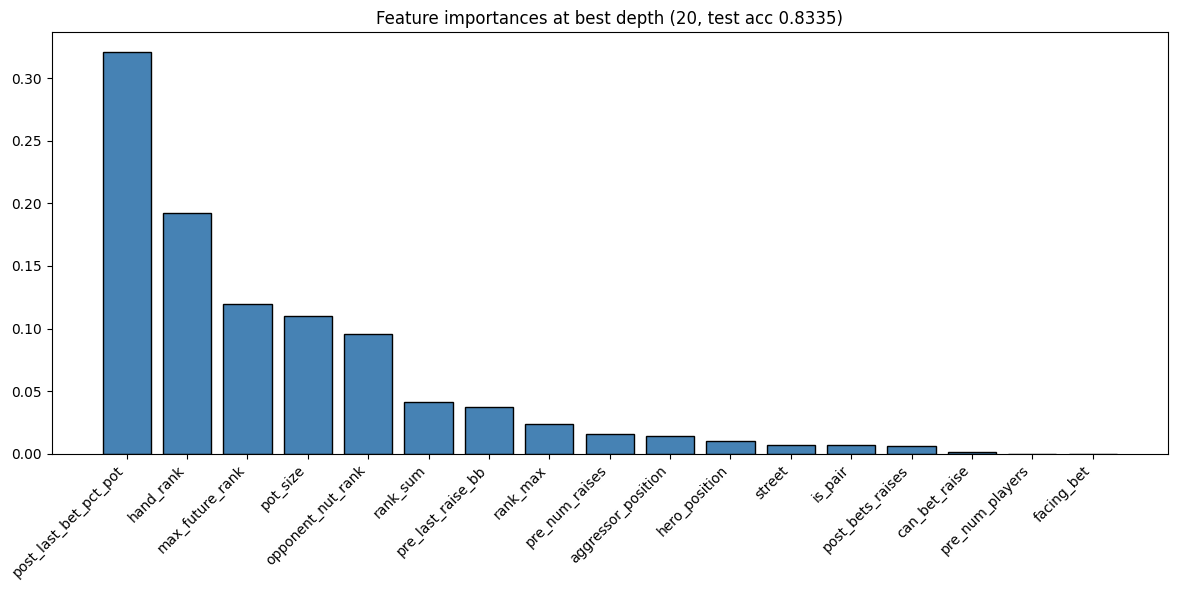

  post_last_bet_pct_pot          0.3207
  hand_rank                      0.1924
  max_future_rank                0.1194
  pot_size                       0.1098
  opponent_nut_rank              0.0955
  rank_sum                       0.0409
  pre_last_raise_bb              0.0371
  rank_max                       0.0235
  pre_num_raises                 0.0153
  aggressor_position             0.0143
  hero_position                  0.0099
  street                         0.0072
  is_pair                        0.0066
  post_bets_raises               0.0059
  can_bet_raise                  0.0013
  pre_num_players                0.0000
  facing_bet                     0.0000


In [20]:
best_clf = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_clf.fit(X_train, y_train)

indices = np.argsort(best_clf.feature_importances_)[::-1]
sorted_features = [feature_cols[i] for i in indices]
sorted_importances = best_clf.feature_importances_[indices]

plt.figure(figsize=(12, 6))
plt.bar(sorted_features, sorted_importances, color='steelblue', edgecolor='black')
plt.title(f'Feature importances at best depth ({best_depth}, '
          f'test acc {test_accs[best_idx]:.4f})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

for feat, imp in zip(sorted_features, sorted_importances):
    print(f'  {feat:30s} {imp:.4f}')

One interesting observation with increased depth is that the opponent's possible rank becomes much more important when combined with other features at a higher depth. This makes sense, as combined with information about how the opponent bet, real poker players can predict which cards their opponents could have, allowing them to predict if they're winning or losing.

## Advanced Player (XGBoost)

For advanced players, I implemented a stronger model called XGBoost. XGBoost learns by focusing on prior misclassifications and weighting the corrections it makes to its decision tree. It then aggregates all the decision trees it built to make a final decision. This is similar to a player learning the game by playing rather than studying. It is harder to explain and/or visualize what the model is doing however.

For the first model, I used the same engineered feature set as above. The model built 500 trees, although it could have stopped early if it was not continuing to improved. It had a similar depth of 6.

[0]	validation_0-mlogloss:1.29472	validation_1-mlogloss:1.29454
[50]	validation_0-mlogloss:0.55814	validation_1-mlogloss:0.55927
[100]	validation_0-mlogloss:0.50265	validation_1-mlogloss:0.50571
[150]	validation_0-mlogloss:0.47174	validation_1-mlogloss:0.47686
[200]	validation_0-mlogloss:0.44557	validation_1-mlogloss:0.45346
[250]	validation_0-mlogloss:0.42702	validation_1-mlogloss:0.43745
[300]	validation_0-mlogloss:0.41139	validation_1-mlogloss:0.42436
[350]	validation_0-mlogloss:0.39840	validation_1-mlogloss:0.41374
[400]	validation_0-mlogloss:0.38696	validation_1-mlogloss:0.40458
[450]	validation_0-mlogloss:0.37815	validation_1-mlogloss:0.39771
[499]	validation_0-mlogloss:0.37012	validation_1-mlogloss:0.39166

Train accuracy: 0.8515
Test accuracy:  0.8397


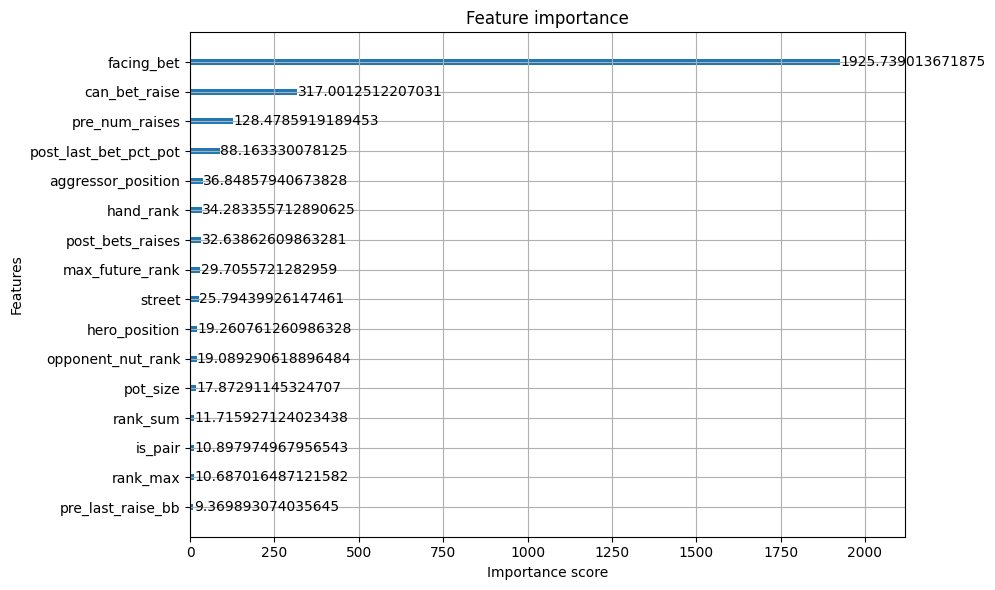

In [21]:
feature_cols = [c for c in df_full.columns if c != 'decision_category']
X = df_full[feature_cols]
y = df_full['decision_category']

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

clf = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    objective='multi:softprob', eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42, n_jobs=-1,
    tree_method='hist',
)
clf.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)], verbose=50)

print(f'\nTrain accuracy: {accuracy_score(y_train, clf.predict(X_train)):.4f}')
print(f'Test accuracy:  {accuracy_score(y_test, clf.predict(X_test)):.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(clf, ax=ax, importance_type='gain', max_num_features=20)
plt.tight_layout(); plt.show()

The XGBoost model achieved a similar test accuracy as the previous depth 20 model, once again suggesting a limit to the features I engineering.

Decisions that were directly correlated with available decisions such as facing_bet, can_bet_raise, or post_last_bet_pct_pot were amongst the most important features. These features were likely favored by the model as it made weighted corrections, since they directly related to the available moves.

The model shows that high accuracy can be achieved with less depth, although the results are less visualizable. This suggests that players don't need to consider a large sequence of decisions in every spot, they just need to rely on intuition based on past experiences.

## Advanced Player (XGBoost with Natural Features)

Finally, in an attempt to create an upper baseline, I created another XGBoost model. Rather than use my engineered features, I encoded the text data to retain as much raw information as possible. This involved the following:
- Card one-hots for every hole + board slot (7 × 52 columns)
- Board aggregate features: suit counts, rank duplications, connectedness
- Per-street action sequence features: counts of bet/raise/check/call, max + sum bet sizes

This resulted in hundreds of features, which is less learnable by a human. Additionally, the XGBoost model was trained to a higher depth of 8, created 1,000 decision trees, and used regularization technices such as subsampling rows and features to help with generalization. The goal was not to create a learnable model, but know how good models could be if we sacrificed explainability.

In [22]:
df_rich = pd.read_parquet(f'{PROCESSED}/df_rich.parquet')
print(f'{df_rich.shape[1]} columns total ({df_rich.shape[1] - df_action.shape[1]} added)')
df_rich.head()

408 columns total (389 added)


,decision_category,is_pair,rank_sum,rank_max,can_bet_raise,facing_bet,hand_category,hand_rank,street,max_future_rank,...,turn_n_check,turn_n_call,turn_max_size,turn_sum_size,river_n_bet,river_n_raise,river_n_check,river_n_call,river_max_size,river_sum_size
0,Check,0,27,14,1,0,two_pair,2526,3,2526,...,1.0,1.0,8.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0
1,Call,0,19,10,1,1,straight,2906,2,2907,...,0.0,0.0,16.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Call,1,24,12,0,1,two_pair,2391,2,3837,...,1.0,0.0,77.0,105.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Check,0,21,11,1,0,two_pair,2248,3,2248,...,0.0,1.0,6.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0
4,Bet/Raise,0,19,14,1,0,high_card,711,3,711,...,1.0,1.0,17.0,23.0,0.0,0.0,1.0,0.0,0.0,0.0


In [23]:
df_rich_nocat = df_rich.drop(columns=['hand_category'], errors='ignore')
feature_cols = [c for c in df_rich_nocat.columns if c != 'decision_category']
X = df_rich_nocat[feature_cols]
y = df_rich_nocat['decision_category']

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

clf = xgb.XGBClassifier(
    n_estimators=1000, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', eval_metric='mlogloss',
    early_stopping_rounds=30, random_state=42, n_jobs=-1,
    tree_method='hist',
)
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

print(f'\nTest accuracy: {accuracy_score(y_test, clf.predict(X_test)):.4f}')

[0]	validation_0-mlogloss:1.33558
[100]	validation_0-mlogloss:0.46397
[200]	validation_0-mlogloss:0.39290
[300]	validation_0-mlogloss:0.36051
[400]	validation_0-mlogloss:0.33861
[500]	validation_0-mlogloss:0.32247
[600]	validation_0-mlogloss:0.31005
[700]	validation_0-mlogloss:0.30003
[800]	validation_0-mlogloss:0.29209
[900]	validation_0-mlogloss:0.28529
[999]	validation_0-mlogloss:0.27929

Test accuracy: 0.8939


The resulting model did achieve the best accuracy of all models at 89%, further showing that the engineered features have limits. However, the accuracy is only slighly higher than high-depth or other XGBoost model, showcasing the success in learning better models toward an upper baseline. The raw data input is the equivalent of "instinct" that professional players have when analyzing all the information in a given moment.

## Conclusions

Based on the gradually improving accuracy observed above, I can conclude that poker is learnable. Models were able to beat the random baseline very easily. They could be general LLMs with a low-depth, visualizable decision tree. They could beat trained LLMs with a high-depth decision tree. They could achieve almost 90% accuracy by using gradient-boosted approaches, showcasing that players who play a lot and learn from their mistakes can develop less explainable skills.

Through the visualized decision trees, I observed that checking occurs in similar spots to betting / raising, while calling / folding occur in similar spots. This can be explained as GTO disguising its hand strength to avoid exploitation.

Through my player profile features, I observed that focusing on a player's own hand strength and possible hand strength in relation to the pot were the most relevant features for deciding between available moves. This can be explained by having an "expected value" mindset.

## Collaborations

Resources:

```
On my honor, I declare the following resources:
1. Collaborators:
- Professor James Caverlee helped me talk through my overall project direction.

2. Web Sources:
- The PokerBench dataset: https://huggingface.co/datasets/RZ412/PokerBench
- The WSOP Main Event dataset: https://www.kaggle.com/datasets/cviaxmiwnptr/wsop-main-event-results-1971-2024/code
- Poker.org Hand Cheatsheet Image: https://www.poker.org/poker-hands-ranking-chart/ 
- PokerNews Hand Strength Image: https://www.pokernews.com/poker-rules/texas-holdem.htm o

3. AI Tools:
- I used Claude to help me refactor my notebook by placing my preprocessing steps into scripts.
- I used Claude to document my preprocessing functions and write test cases to confirm the intended results.

4. Citations:
- Richard Zhuang, Akshat Gupta, Richard Yang, Aniket Rahane, Zhengyu Li, and Gopala Anumanchipalli. “PokerBench: Training Large Language Models to Become Professional Poker Players.” Proceedings of the AAAI Conference on Artificial Intelligence (AAAI), 2025.
```